<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Gas_CO_RegresionMul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación: Regresión Lineal Múltiple
## Predicción de Emisiones de CO en Turbinas de Gas
Helen Janko Sanga Ing.Sistemas

## 1. Carga y Preparación del Dataset

Se implementa la regresion lineal multivariable para predecir las **emisiones de Monoxido de Carbono (CO)**
de una turbina de gas. El dataset proviene del repositorio UCI Machine Learning y contiene lecturas de
sensores de una turbina de gas de Turquia durante 5 años (2011–2015). Cada fila representa 1 hora de operacion.

El archivo contiene **11 variables** en total. Se usan las **9 primeras columnas como features** (variables de entrada)
y el **CO (columna 9) como variable objetivo** a predecir:

| Columna | Variable | Descripcion | Unidad |
|---------|----------|-------------|--------|
| 0 | AT | Temperatura Ambiente | °C |
| 1 | AP | Presion Ambiente | mbar |
| 2 | AH | Humedad Relativa | % |
| 3 | AFDP | Diferencial de Presion en Filtro de Aire | mbar |
| 4 | GTEP | Potencia del Exhaust de la Turbina | MW |
| 5 | TIT | Temperatura de Entrada a la Turbina | °C |
| 6 | TAT | Temperatura de Salida de la Turbina | °C |
| 7 | TEY | Rendimiento Energetico | MWH |
| 8 | CDP | Presion de Descarga del Compresor | mbar |
| **9** | **CO** | **Emision de Monoxido de Carbono (OBJETIVO)** | **mg/m³** |
| 10 | NOx | Emision de Oxidos de Nitrogeno | mg/m³ |

Los 5 archivos anuales (2011 al 2015) se leen por separado y se apilan en una sola matriz
usando `np.vstack`, quedando todos los registros juntos para el entrenamiento.

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficacion (trazado de graficos)
from matplotlib import pyplot

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1. Definir la ruta
path = '/content/drive/MyDrive/Colab_Projects_AI/datasets/gas_turbine_co_and_nox_emission_data_set'
archivos = ['gt_2011.csv', 'gt_2012.csv', 'gt_2013.csv', 'gt_2014.csv', 'gt_2015.csv']

# 2. Leer cada archivo y meterlo en una lista de matrices
datasets = []
for f in archivos:
    # delimiter=',' porque es un CSV
    # skiprows=1 para saltar los nombres de las columnas
    data = np.loadtxt(os.path.join(path, f), delimiter=',', skiprows=1)
    datasets = datasets + [data]

# 3. Unir todos en una sola matriz gigante
# Usamos vstack para apilar uno debajo del otro
data_total = np.vstack(datasets)

print(f"Forma de la matriz unificada: {data_total.shape}")

Forma de la matriz unificada: (36733, 11)


In [5]:
# Aislar la variable objetivo (y) y las caracteristicas (X)
# Features: AT, AP, AH, AFDP, GTEP, TIT, TAT, TEY, CDP (columnas 0 a 8)
# Objetivo: CO (columna 9)
X = data_total[:, :9]   # todas las columnas del 0 al 8
y = data_total[:, 9]    # CO: Emision de Monoxido de Carbono (mg/m3)
m = y.size

print(m)
# imprimir algunos puntos de datos
print('{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}{:>8s}'.format(
      'AT','AP','AH','AFDP','GTEP','TIT','TAT','TEY','CDP','CO'))
print('-'*80)
for i in range(10):
    print('{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}{:8.2f}'.format(
          X[i,0],X[i,1],X[i,2],X[i,3],X[i,4],X[i,5],X[i,6],X[i,7],X[i,8],y[i]))

36733
      AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP      CO
--------------------------------------------------------------------------------
    4.59 1018.70   83.67    3.58   23.98 1086.20  549.83  134.67   11.90    0.33
    4.29 1018.30   84.23    3.57   23.95 1086.10  550.05  134.67   11.89    0.45
    3.90 1018.40   84.86    3.58   23.99 1086.50  550.19  135.10   12.04    0.45
    3.74 1018.30   85.43    3.58   23.91 1086.50  550.17  135.03   11.99    0.23
    3.75 1017.80   85.18    3.58   23.92 1085.90  550.00  134.67   11.91    0.27
    3.89 1017.70   83.95    3.58   23.90 1086.00  549.98  134.67   11.87    0.23
    3.67 1018.00   84.11    3.58   23.89 1085.90  550.04  134.68   11.88    0.44
    3.59 1018.20   83.87    3.58   23.88 1086.00  549.88  134.66   11.89    0.80
    3.71 1018.50   84.95    3.60   23.96 1086.30  549.98  134.65   11.87    0.69
    4.83 1018.50   85.35    3.52   23.42 1083.10  549.80  132.67   11.69    1.03


## 2. Seleccion de Variables y Normalizacion

<a id="section4"></a>
### 2.1 Normalizacion de caracteristicas

Al observar los datos se nota que cada sensor maneja magnitudes muy distintas:
por ejemplo la Presion Ambiente (AP) ronda los **1013 mbar** mientras que el Diferencial
de Presion del Filtro (AFDP) ronda los **3.9 mbar**. Si se entrena el modelo con esas
diferencias, el descenso por el gradiente tardaria muchisimo en converger porque los pasos
de actualizacion de theta serian muy disparejos entre features.

La solucion es transformar cada feature para que tenga **media 0 y desviacion estandar 1**,
lo que se conoce como normalizacion Z-score:

$$ x_j = \frac{x_j - \mu_j}{\sigma_j} $$

La desviacion estandar es una forma de medir cuanta variacion hay en el rango de valores de una
caracteristica en particular. En `numpy`, se puede usar la funcion `std` para calcularla.

<div class="alert alert-block alert-warning">
<b>Notas para la implementacion:</b> Cuando se normalize una caracteristica, es importante almacenar
los valores usados para la normalizacion — el valor de la media y el valor de la desviacion estandar.
Despues de aprender los parametros del modelo, si se quiere predecir el CO para nuevas condiciones
de la turbina, primero se deben normalizar esos valores usando los mismos mu y sigma del entrenamiento.
</div>

In [6]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [7]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviacion estandar calculada:', sigma)

Media calculada: [  17.71272625 1013.07016497   77.86701549    3.92551771   25.56380138
 1081.42808374  546.15851714  133.50640351   12.06052515]
Desviacion estandar calculada: [ 7.44734986  6.46325798 14.4611581   0.77392506  4.19590035 17.53613423
  6.8422673  15.61842177  1.08878048]


Despues de que `featureNormalize` es probada, se añade el termino de interseccion a `X_norm`.
Esta columna de unos permite que el modelo aprenda el valor de $\theta_0$, que es el intercepto
de la recta — es decir, el valor base del CO cuando todas las features normalizadas valen cero:

In [8]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("Forma de X con termino de interseccion:", X.shape)
print("  -> 10 parametros theta a aprender (1 intercepto + 9 sensores)")

Forma de X con termino de interseccion: (36733, 10)
  -> 10 parametros theta a aprender (1 intercepto + 9 sensores)


## 3. Graficacion de Datos

Antes de entrenar el modelo es util visualizar la relacion entre los sensores y el CO.
Se grafican los dos sensores con mayor correlacion con las emisiones:

- **TIT (Temperatura de Entrada a la Turbina):** a mayor temperatura de combustion, la quema
es mas completa y se genera menos CO. Por eso se espera una relacion negativa.
- **AT (Temperatura Ambiente):** afecta las condiciones de entrada al compresor y por ende
la eficiencia de la combustion.

In [9]:
def graficarDatos(x, y, xlabel, ylabel):
    pyplot.figure(figsize=(8, 5))
    pyplot.plot(x, y, 'ro', markersize=2, alpha=0.4)
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)
    pyplot.title(f'{xlabel} vs {ylabel}')
    pyplot.grid(True)

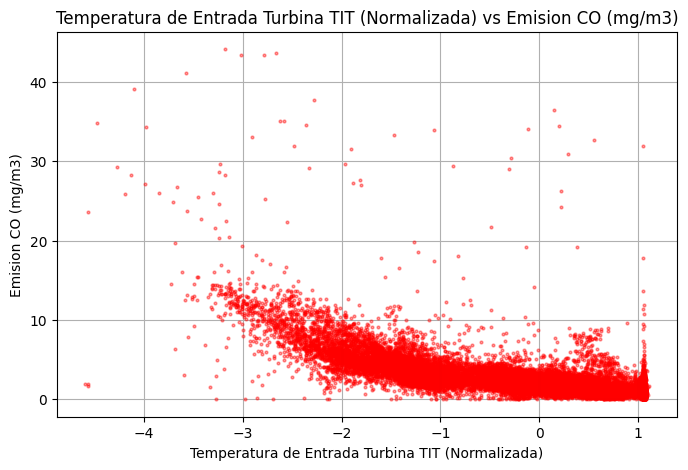

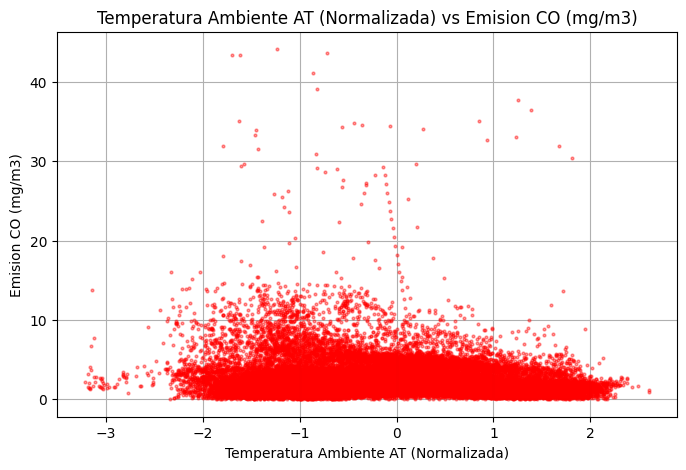

In [10]:
# Graficamos los dos sensores con mayor correlacion con el CO
# X_norm columna 5 = TIT (normalizada), columna 0 = AT (normalizada)
graficarDatos(X_norm[:, 5], y, 'Temperatura de Entrada Turbina TIT (Normalizada)', 'Emision CO (mg/m3)')
pyplot.show()

graficarDatos(X_norm[:, 0], y, 'Temperatura Ambiente AT (Normalizada)', 'Emision CO (mg/m3)')
pyplot.show()

## 4. Funciones Matematicas: Costo y Descenso por el Gradiente

<a id="section5"></a>
### 4.1 Descenso por el gradiente

La unica diferencia con la regresion lineal simple es que ahora existen mas caracteristicas en
la matriz $X$. La funcion de hipotesis y la regla de actualizacion del descenso del gradiente
por lotes permanecen sin cambios.

Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

<div class="alert alert-block alert-warning">
<b>Nota de implementacion:</b> En el caso de multivariables, la funcion de costo puede se escrita
considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numerico como `numpy`.
</div>

En este dataset, $\theta$ es un vector de **10 valores**: uno por cada sensor (AT, AP, AH, AFDP, GTEP,
TIT, TAT, TEY, CDP) mas el intercepto $\theta_0$. En cada iteracion, el gradiente ajusta los 10 valores
simultaneamente buscando reducir el error entre el CO predicho y el CO real.

In [11]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [12]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual sera actualizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 4.1.1 Seleccionando coeficientes de aprendizaje

Se elige un valor para alpha y se ejecuta el descenso por el gradiente. Se uso `alpha = 0.01`
con 600 iteraciones. El objetivo es que la grafica de convergencia muestre que el costo J
**disminuye en cada iteracion** hasta estabilizarse — eso indica que el modelo esta aprendiendo
correctamente y que el alpha elegido es adecuado.

Si la curva bajara y luego subiera, significaria que el alpha es demasiado grande y habria que reducirlo.

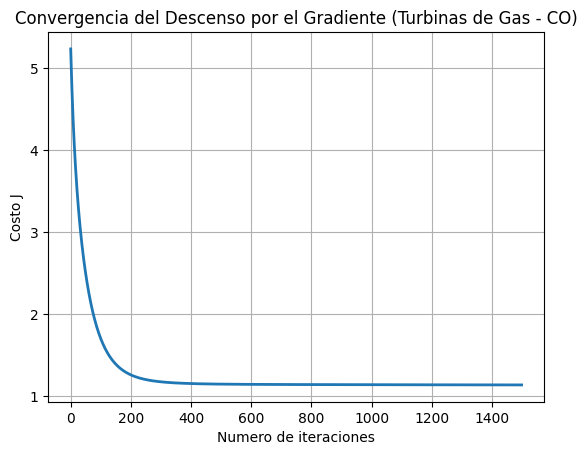

theta calculado por el descenso por el gradiente: [ 2.37246758  0.00420093  0.02699945 -0.12970515 -0.12256028  0.07195338
 -1.1882484  -0.89262248 -0.57168968 -0.24999139]


In [14]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 1500

# inicializa theta con ceros — ahora son 10 valores (1 intercepto + 9 sensores)
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente (Turbinas de Gas - CO)')
pyplot.grid(True)
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

## 5. Entrenamiento del Modelo de Regresion Multiple

Una vez obtenidos los valores de theta, se calculan las predicciones de CO para todos los
registros del dataset. La grafica muestra cada par (CO predicho, CO real) como un punto verde.

Si el modelo fuera perfecto, todos los puntos caerian sobre la linea negra diagonal.
La dispersion alrededor de esa linea representa el error del modelo — cuanto mas concentrados
esten los puntos sobre la diagonal, mejor es la prediccion.

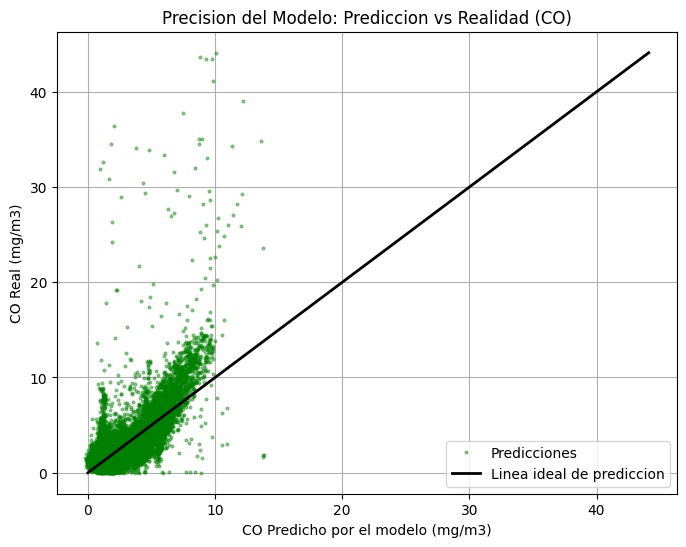

In [15]:
# Grafica: Predicciones de la IA vs Valores Reales de CO
predicciones = np.dot(X, theta)

pyplot.figure(figsize=(8, 6))
pyplot.plot(predicciones, y, 'go', markersize=2, alpha=0.4)
# Dibujamos una linea diagonal perfecta para comparar
pyplot.plot([y.min(), y.max()], [y.min(), y.max()], 'k-', lw=2)
pyplot.xlabel('CO Predicho por el modelo (mg/m3)')
pyplot.ylabel('CO Real (mg/m3)')
pyplot.title('Precision del Modelo: Prediccion vs Realidad (CO)')
pyplot.legend(['Predicciones', 'Linea ideal de prediccion'])
pyplot.grid(True)
pyplot.show()

## 6. Ecuacion de la Normal

<a id="section7"></a>

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion
exacta con un solo calculo: no hay "bucles de convergencia" como en el descenso por el gradiente.

En el caso de este dataset, la Ecuacion Normal toma los **36,733 registros con los 9 sensores**
y resuelve directamente el sistema de ecuaciones que minimiza el error. El resultado es el mismo
theta optimo al que el gradiente converge, pero obtenido de forma analitica.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que
no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$
para tener el termino de interseccion ($\theta_0$).

In [16]:
# Recargar datos originales (sin normalizar) para la Ecuacion Normal
X_original = data_total[:, :9]
y_original  = data_total[:, 9]
m_original  = y_original.size

# Añadir columna de unos
X_normal_eq = np.concatenate([np.ones((m_original, 1)), X_original], axis=1)

print("Forma de X para la Ecuacion Normal:", X_normal_eq.shape)

Forma de X para la Ecuacion Normal: (36733, 10)


In [17]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    # Formula: theta = (X^T * X)^-1 * X^T * y
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)

    return theta

In [18]:
# Calcula los parametros con la ecuacion de la normal
theta_normal = normalEqn(X_normal_eq, y_original)

# Muestra los resultados obtenidos
print('Theta calculado a partir de la ecuacion de la normal: {:s}'.format(str(theta_normal)))

Theta calculado a partir de la ecuacion de la normal: [ 1.28742019e+02 -4.99269704e-02 -3.67455586e-03 -7.98265650e-03
 -1.38750725e-01  9.67465515e-02 -7.11024072e-02 -8.07108866e-02
 -1.92054477e-01  1.95215382e+00]


## 7. Evaluacion Matematica del Modelo

Se evalua el modelo con tres metricas:

- **MSE** (Error Cuadratico Medio): promedio de los errores al cuadrado. Penaliza fuerte los errores grandes.
- **RMSE** (Raiz del MSE): el error expresado en las mismas unidades que el CO (mg/m³). Es el mas intuitivo — representa cuanto se equivoca el modelo en promedio por cada prediccion.
- **R²** (Coeficiente de Determinacion): indica que porcentaje de la variabilidad del CO logra explicar el modelo. Un R² de 1.0 seria prediccion perfecta.

El CO es una variable con **comportamiento no lineal** — la turbina genera picos de CO en
arranque, apagado y cambios bruscos de operacion que un modelo lineal no puede capturar completamente.
Por eso un R² del 55–56% es un resultado esperado y valido para un modelo lineal sobre este dataset.

In [19]:
# Calculamos las predicciones para todos los datos con ambos metodos
predicciones_gradiente = np.dot(X, theta)
predicciones_normal    = np.dot(X_normal_eq, theta_normal)

# ── Metrica para el Descenso por el Gradiente ─────────────────────────────────
mse_g    = np.mean(np.square(predicciones_gradiente - y))
rmse_g   = np.sqrt(mse_g)
ss_res_g = np.sum(np.square(y - predicciones_gradiente))
ss_tot   = np.sum(np.square(y - np.mean(y)))
r2_g     = 1 - (ss_res_g / ss_tot)

# ── Metrica para la Ecuacion Normal ──────────────────────────────────────────
mse_n    = np.mean(np.square(predicciones_normal - y_original))
rmse_n   = np.sqrt(mse_n)
ss_res_n = np.sum(np.square(y_original - predicciones_normal))
ss_tot_n = np.sum(np.square(y_original - np.mean(y_original)))
r2_n     = 1 - (ss_res_n / ss_tot_n)

print('-' * 55)
print(' METRICAS DE EVALUACION DEL MODELO (CO) ')
print('-' * 55)
print('  [Descenso por el Gradiente]')
print('  MSE  (Error Cuadratico Medio):  {:.4f}'.format(mse_g))
print('  RMSE (Desviacion del Error):    {:.4f} mg/m3'.format(rmse_g))
print('  R^2  (Varianza Explicada):      {:.2f} %'.format(r2_g * 100))
print()
print('  [Ecuacion Normal]')
print('  MSE  (Error Cuadratico Medio):  {:.4f}'.format(mse_n))
print('  RMSE (Desviacion del Error):    {:.4f} mg/m3'.format(rmse_n))
print('  R^2  (Varianza Explicada):      {:.2f} %'.format(r2_n * 100))
print('-' * 55)
if r2_g > 0.8:
    print(' Conclusion: El modelo tiene una Varianza > 80%, es EXCELENTE para predecir.')
elif r2_g > 0.6:
    print(' Conclusion: El modelo tiene varianza aceptable, puede mejorarse.')
else:
    print(' Conclusion: El modelo lineal captura la tendencia general del CO.')
    print(' El comportamiento no lineal del CO limita el R^2 de un modelo lineal.')

-------------------------------------------------------
 METRICAS DE EVALUACION DEL MODELO (CO) 
-------------------------------------------------------
  [Descenso por el Gradiente]
  MSE  (Error Cuadratico Medio):  2.2695
  RMSE (Desviacion del Error):    1.5065 mg/m3
  R^2  (Varianza Explicada):      55.67 %

  [Ecuacion Normal]
  MSE  (Error Cuadratico Medio):  2.2350
  RMSE (Desviacion del Error):    1.4950 mg/m3
  R^2  (Varianza Explicada):      56.34 %
-------------------------------------------------------
 Conclusion: El modelo lineal captura la tendencia general del CO.
 El comportamiento no lineal del CO limita el R^2 de un modelo lineal.


## 8. Simulador Final: Prediccion de Emisiones de CO

Dado un conjunto de condiciones operativas de la turbina, el modelo predice cuantos mg/m³
de CO se emitiran en esa hora de operacion. Se comparan ambos metodos sobre las mismas condiciones.

> **Nota importante:** Para el metodo del Gradiente, los valores nuevos deben normalizarse
> con los mismos `mu` y `sigma` usados durante el entrenamiento. Para la Ecuacion Normal
> se usan los valores originales sin normalizar.

In [20]:
print('=' * 60)
print('  SIMULADOR DE EMISIONES DE CO — TURBINA DE GAS ')
print('=' * 60)
print('Objetivo: Predecir la Emision de CO (mg/m3)')
print('-' * 60)

# Condiciones operativas a simular
# Orden: [AT, AP, AH, AFDP, GTEP, TIT, TAT, TEY, CDP]
valores_sensores = [15.0, 1013.0, 80.0, 4.0, 25.0, 1080.0, 550.0, 130.0, 12.0]

print('Ingresando condiciones actuales al sistema:')
nombres = ['AT  (Temp. Ambiente)          ', 'AP  (Presion Ambiente)        ',
           'AH  (Humedad Relativa)        ', 'AFDP(Dif. Pres. Filtro)       ',
           'GTEP(Potencia Exhaust)        ', 'TIT (Temp. Entrada Turbina)   ',
           'TAT (Temp. Salida Turbina)    ', 'TEY (Rendimiento Energetico)  ',
           'CDP (Pres. Descarga Compresor)']
for nombre, valor in zip(nombres, valores_sensores):
    print('  * {}: {}'.format(nombre, valor))
print('-' * 60)

# Prediccion con la Ecuacion Normal (sin normalizar)
X_array_normal = [1] + valores_sensores
co_normal = np.dot(X_array_normal, theta_normal)

# Prediccion con Descenso por el Gradiente (normalizando con mu y sigma del entrenamiento)
valores_normalizados = (np.array(valores_sensores) - mu) / sigma
X_array_gradiente = np.concatenate([[1], valores_normalizados])
co_gradiente = np.dot(X_array_gradiente, theta)

print(' RESULTADOS:')
print('  [Metodo 1 — Ecuacion de la Normal]')
print('   => Emision de CO predicha: {:.2f} mg/m3'.format(co_normal))
print()
print('  [Metodo 2 — Descenso por el Gradiente]')
print('   => Emision de CO predicha: {:.2f} mg/m3'.format(co_gradiente))
print('=' * 60)

  SIMULADOR DE EMISIONES DE CO — TURBINA DE GAS 
Objetivo: Predecir la Emision de CO (mg/m3)
------------------------------------------------------------
Ingresando condiciones actuales al sistema:
  * AT  (Temp. Ambiente)          : 15.0
  * AP  (Presion Ambiente)        : 1013.0
  * AH  (Humedad Relativa)        : 80.0
  * AFDP(Dif. Pres. Filtro)       : 4.0
  * GTEP(Potencia Exhaust)        : 25.0
  * TIT (Temp. Entrada Turbina)   : 1080.0
  * TAT (Temp. Salida Turbina)    : 550.0
  * TEY (Rendimiento Energetico)  : 130.0
  * CDP (Pres. Descarga Compresor): 12.0
------------------------------------------------------------
 RESULTADOS:
  [Metodo 1 — Ecuacion de la Normal]
   => Emision de CO predicha: 2.77 mg/m3

  [Metodo 2 — Descenso por el Gradiente]
   => Emision de CO predicha: 2.07 mg/m3


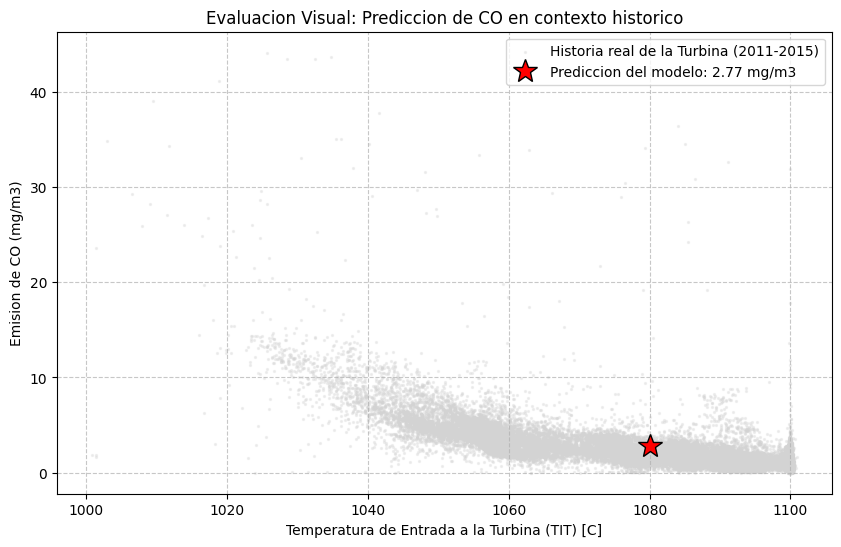

In [21]:
# Grafica final: la prediccion dentro del contexto historico
pyplot.figure(figsize=(10, 6))

# Nube de datos historicos TIT vs CO
pyplot.scatter(data_total[:, 5], data_total[:, 9],
               color='lightgray', alpha=0.3, s=2,
               label='Historia real de la Turbina (2011-2015)')

# La prediccion simulada
pyplot.plot(valores_sensores[5], co_normal,
            'r*', markersize=18, markeredgecolor='black',
            label='Prediccion del modelo: {:.2f} mg/m3'.format(co_normal))

pyplot.xlabel('Temperatura de Entrada a la Turbina (TIT) [C]')
pyplot.ylabel('Emision de CO (mg/m3)')
pyplot.title('Evaluacion Visual: Prediccion de CO en contexto historico')
pyplot.legend(loc='upper right')
pyplot.grid(True, linestyle='--', alpha=0.7)
pyplot.show()